In [1]:
from sympy import symbols, groebner, Poly

b1, b2, b3, b4, b5, b6, x1, x2, x3 = symbols("b1 b2 b3 b4 b5 b6 x1 x2 x3")

f1 = b1 * (x2 + x3) - x1 * x2
f2 = b2 * (x2 + x3) - x1 * x3
f3 = b3 * (x1 + x3) - x1 * x2
f4 = b4 * (x1 + x3) - x2 * x3
f5 = b5 * (x2 + x1) - x2 * x3
f6 = b6 * (x1 + x2) - x1 * x3
f7 = 1 - x1 - x2 - x3
f8 = b1 + b2 + b3 + b4 + b5 + b6 - 1

H= groebner(
    [f1, f2, f3, f4, f5, f6, f7, f8],
    x1,
    x2,
    x3,
    b1,
    b2,
    b3,
    b4,
    b5,
    b6,
    order="lex",
    method="f5b",
)
len(H), H[:]

(11,
 [b3 + b4 + b5 + b6 + x1 - 1,
  -b3 - b4 + x2,
  -b5 - b6 + x3,
  b1 + b2 + b3 + b4 + b5 + b6 - 1,
  b2*b3 + b2*b4 + b2*b5 + b2*b6 + b5*b6 + b6**2 - b6,
  2*b2*b4*b5 + b2*b4 + 2*b2*b5**2 - 3*b2*b5 - 2*b2*b6**2 - b4*b6 - 2*b5**2*b6 - 4*b5*b6**2 + 2*b5*b6 - 2*b6**3 + 2*b6**2,
  2*b2*b4*b6 + b2*b4 - b2*b5 + 2*b4*b5*b6 + 2*b4*b6**2 - b4*b6,
  b2*b5*b6 + b2*b5 + b2*b6**2 + b5**2*b6 + 2*b5*b6**2 - b5*b6 + b6**3 - b6**2,
  b3*b4 + b4**2 - b4 - b5**2 - b5*b6 + b5,
  b3*b5 + b3*b6 + b4*b5 + b4*b6 + b5**2 + b5*b6 - b5,
  b4*b5**2 + b4*b5*b6 + b4*b6 + b5**3 + 2*b5**2*b6 - b5**2 + b5*b6**2 - b5*b6])

Found 50000 feasible points out of 50000 trials.
b1: min=0.0008, max=0.8629
b2: min=0.0000, max=0.6604
b3: min=0.0037, max=0.8277
b4: min=0.0004, max=0.9399
b5: min=0.0004, max=0.7175
b6: min=0.0000, max=0.3816


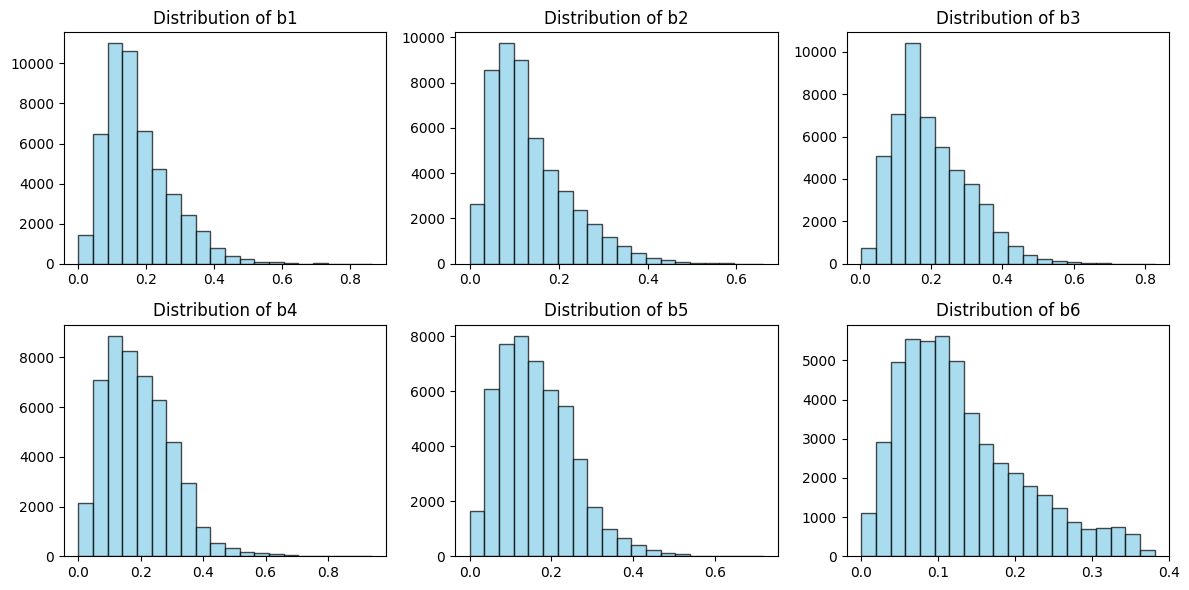

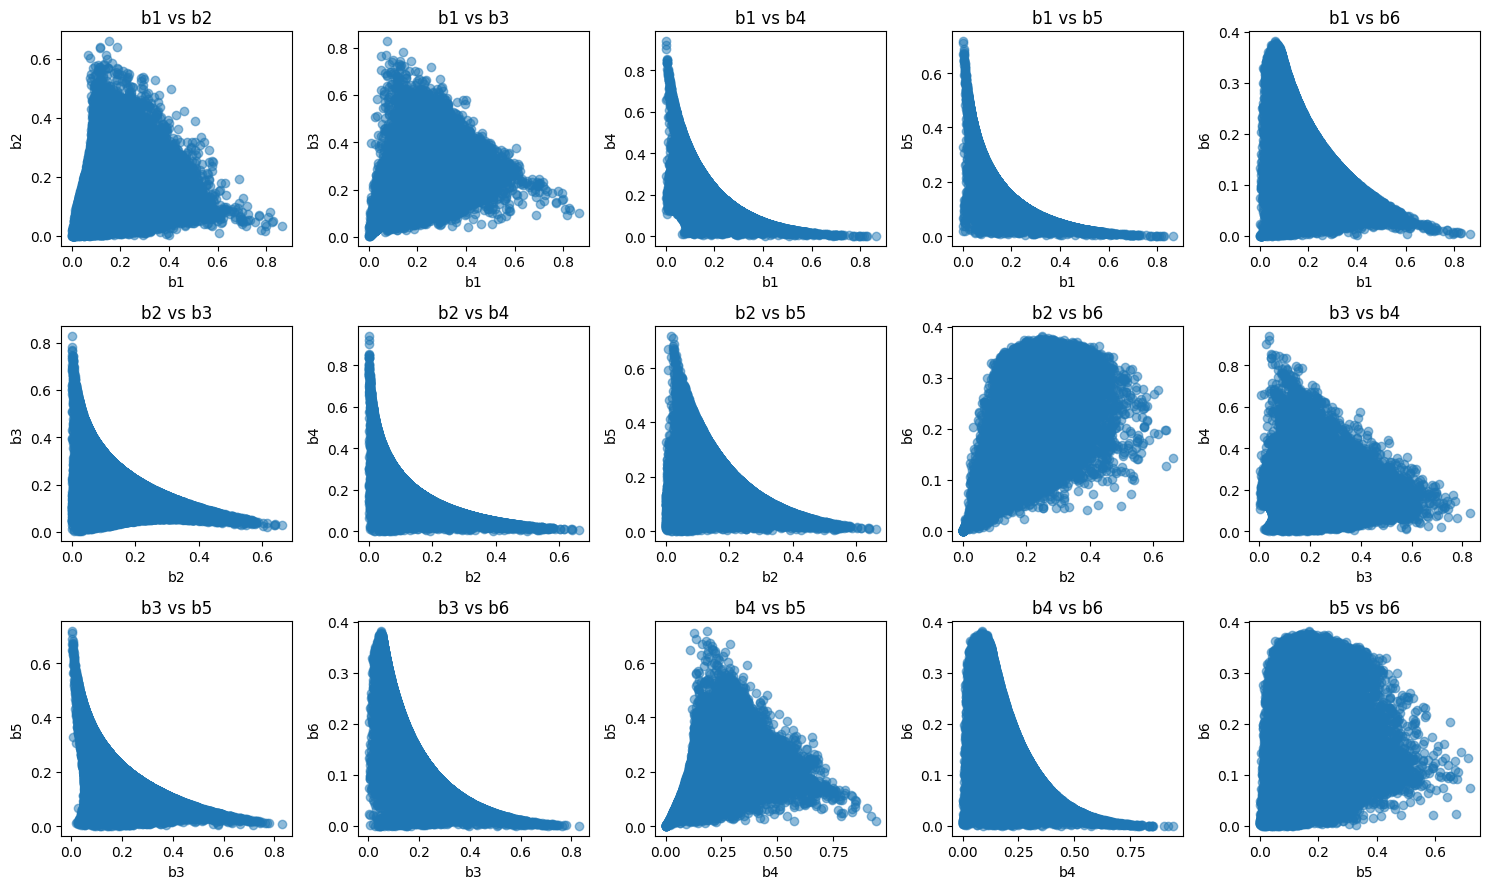

In [2]:
import numpy as np
from scipy.optimize import root, least_squares
import matplotlib.pyplot as plt


# Define b-polynomials (b-only) from Groebner basis
def p1(b):
    b1, b2, b3, b4, b5 = b
    b6 = 1 - sum(b)
    return b2 * b3 + b2 * b4 + b2 * b5 + b2 * b6 + b5 * b6 + b6**2 - b6


def p2(b):
    b1, b2, b3, b4, b5 = b
    b6 = 1 - sum(b)
    return (
        2 * b2 * b4 * b5
        + b2 * b4
        + 2 * b2 * b5**2
        - 3 * b2 * b5
        - 2 * b2 * b6**2
        - b4 * b6
        - 2 * b5**2 * b6
        - 4 * b5 * b6**2
        + 2 * b5 * b6
        - 2 * b6**3
        + 2 * b6**2
    )


def p3(b):
    b1, b2, b3, b4, b5 = b
    b6 = 1 - sum(b)
    return (
        2 * b2 * b4 * b6
        + b2 * b4
        - b2 * b5
        + 2 * b4 * b5 * b6
        + 2 * b4 * b6**2
        - b4 * b6
    )


def p4(b):
    b1, b2, b3, b4, b5 = b
    b6 = 1 - sum(b)
    return (
        b2 * b5 * b6
        + b2 * b5
        + b2 * b6**2
        + b5**2 * b6
        + 2 * b5 * b6**2
        - b5 * b6
        + b6**3
        - b6**2
    )


def p5(b):
    b1, b2, b3, b4, b5 = b
    b6 = 1 - sum(b)
    return b3 * b4 + b4**2 - b4 - b5**2 - b5 * b6 + b5


def p6(b):
    b1, b2, b3, b4, b5 = b
    b6 = 1 - sum(b)
    return b3 * b5 + b3 * b6 + b4 * b5 + b4 * b6 + b5**2 + b5 * b6 - b5


def p7(b):
    b1, b2, b3, b4, b5 = b
    b6 = 1 - sum(b)
    return (
        b4 * b5**2
        + b4 * b5 * b6
        + b4 * b6
        + b5**3
        + 2 * b5**2 * b6
        - b5**2
        + b5 * b6**2
        - b5 * b6
    )


polys = [p1, p2, p3, p4, p5, p6, p7]


def fvec(b):
    return [p(b) for p in polys]


# Function to find a feasible point starting from a guess
def find_feasible_point(b_guess):
    sol = least_squares(fvec, b_guess, bounds=(0, 1), method="trf")
    if sol.success and sol.cost < 1e-10:
        b_sol = sol.x
        b6_sol = 1 - sum(b_sol)
        b_full = np.append(b_sol, b6_sol)
        if np.all(b_full >= -1e-6):
            return np.clip(b_full, 0, None)
    return None


# Generate multiple feasible points by perturbing initial guesses
n_samples = 50_000
feasible_points = []

for _ in range(n_samples):
    # random initial guess in simplex
    b_guess = np.random.dirichlet(np.ones(5))
    b = find_feasible_point(b_guess)
    if b is not None:
        feasible_points.append(b)

feasible_points = np.array(feasible_points)
print(f"Found {len(feasible_points)} feasible points out of {n_samples} trials.")

# Min/max for each b_i
for i in range(6):
    print(
        f"b{i+1}: min={feasible_points[:,i].min():.4f}, max={feasible_points[:,i].max():.4f}"
    )

# Histograms for each b_i
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
for i in range(6):
    axes[i].hist(
        feasible_points[:, i], bins=20, alpha=0.7, color="skyblue", edgecolor="black"
    )
    axes[i].set_title(f"Distribution of b{i+1}")
plt.tight_layout()
plt.show()

# 2D scatter plots: for all pairs (b1, b2), (b1, b3), ..., (b5, b6)
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()
pair_idx = 0
for i in range(6):
    for j in range(i + 1, 6):
        axes[pair_idx].scatter(
            feasible_points[:, i], feasible_points[:, j], alpha=0.5
        )
        axes[pair_idx].set_xlabel(f"b{i+1}")
        axes[pair_idx].set_ylabel(f"b{j+1}")
        axes[pair_idx].set_title(f"b{i+1} vs b{j+1}")
        pair_idx += 1
plt.tight_layout()
plt.show()

In [3]:
feasible_points[:2, [0, 3, 5]].prod(axis=1), feasible_points[:2, [1, 2, 4]].prod(axis=1)

(array([0.0020899 , 0.00319841]), array([0.0020899 , 0.00319841]))

In [4]:
feasible_points[0, [0, 3, 5]].prod(), feasible_points[0, [1, 2, 4]].prod(
)

(np.float64(0.0020899029493489252), np.float64(0.0020899029663186846))

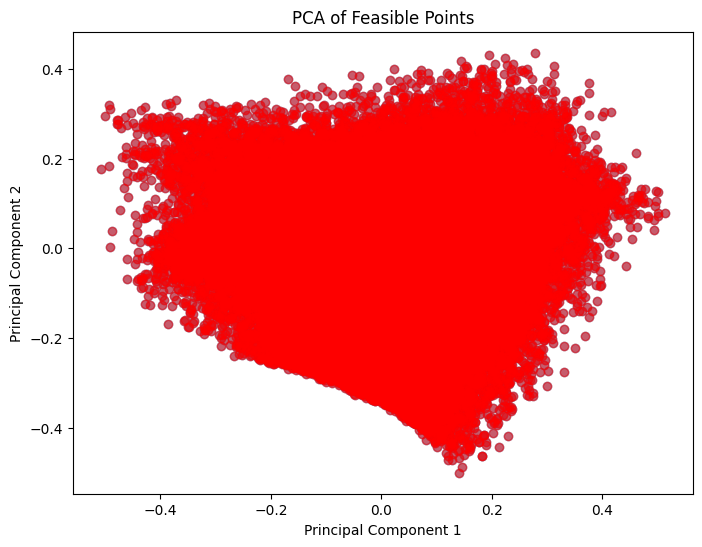

In [5]:
### PCA Visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(feasible_points)
mask = (feasible_points[:,[0,3,5]].prod(axis=1) != feasible_points[:,[1,2,4]].prod(axis=1))
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.scatter(pca_result[mask, 0], pca_result[mask, 1], color='red', alpha=0.5)
plt.title("PCA of Feasible Points")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

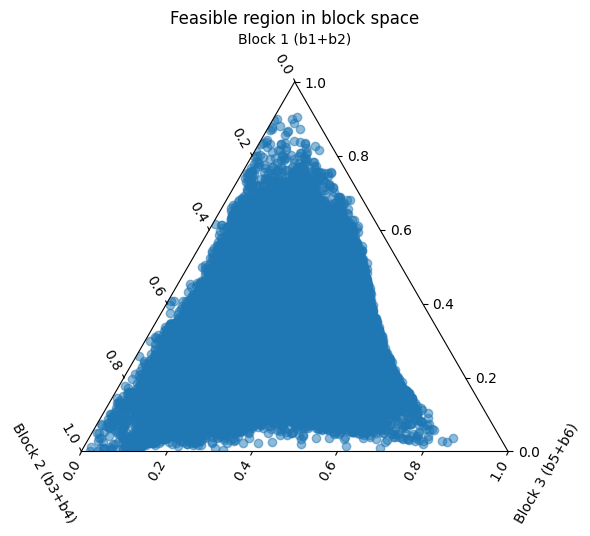

In [6]:
blocks = np.array([feasible_points[:, [0,1]].sum(axis=1), feasible_points[:, [2,3]].sum(axis=1), feasible_points[:, [4,5]].sum(axis=1)]).T
# Plot probability simplex for blocks
import mpltern
ax = plt.subplot(111, projection='ternary')
ax.scatter(blocks[:,0], blocks[:,1], blocks[:,2], alpha=0.5)
ax.set_tlabel('Block 1 (b1+b2)')
ax.set_llabel('Block 2 (b3+b4)')
ax.set_rlabel('Block 3 (b5+b6)')
plt.title("Feasible region in block space")
plt.show()

In [7]:
blocks.sum(axis=1)  # Should be all ones

array([1., 1., 1., ..., 1., 1., 1.], shape=(50000,))

In [8]:
import numpy as np


def solve_y_from_b(b):
    b1, b2, b3, b4, b5, b6 = b
    A = np.array([[-b3, b1, 0.0], [-b6, 0.0, b2], [0.0, -b5, b4]], dtype=float)
    r = np.array([b3 - b1, b6 - b2, b5 - b4], dtype=float)
    if np.linalg.matrix_rank(A) == np.linalg.matrix_rank(np.vstack([A, r])):
        if np.linalg.matrix_rank(A) == A.shape[1]:
            print("A is full rank, unique solution exists")
        if np.linalg.matrix_rank(A) < A.shape[1]:
            print("A is rank deficient, infinite solutions exist")
    if np.linalg.det(A) == 0:
        print("Warning: A is singular, cannot solve uniquely")
        print("Compute least squares solution regarding the residuals instead")
        A_plus = np.linalg.pinv(A)
        y = A_plus @ r + (np.eye(A.shape[1]) - A_plus @ A)@np.ones(A.shape[1])
        print("Matrix A:\n", A)
        print("Target r:", r)
        return y, None
    svals = np.linalg.svd(A, compute_uv=False)
    if svals[-1] < 1e-12:
        # near-singular: fallback to least-squares solution (SVD) and warn
        print("Warning: A is near-singular, using least-squares solution")
        print("Matrix A:\n", A)
        print("Target r:", r)
        y, *_ = np.linalg.lstsq(A, r, rcond=None)
        return y, svals
    y = np.linalg.solve(A, r)
    return y, svals


def compute_x_from_y(y):
    return y / (1.0 + y)


def residuals_all(b, x):
    x1, x2, x3 = x.tolist()
    b1, b2, b3, b4, b5, b6 = b
    # original residuals
    r1 = b1 - x1 * (x2 / (1 - x1))
    r2 = b2 - x1 * (x3 / (1 - x1))
    r3 = b3 - x2 * (x1 / (1 - x2))
    r4 = b4 - x2 * (x3 / (1 - x2))
    r5 = b5 - x3 * (x2 / (1 - x3))
    r6 = b6 - x3 * (x1 / (1 - x3))
    return np.array([r1, r2, r3, r4, r5, r6])

def probs_x(x):
    x1,x2,x3 = x.tolist()
    p1 = (x1/(x1+x2+x3))*(x2/(x2+x3))
    p2 = (x1/(x1+x2+x3))*(x3/(x2+x3))
    p3 = (x2/(x1+x2+x3))*(x1/(x1+x3))
    p4 = (x2/(x1+x2+x3))*(x3/(x1+x3))
    p5 = (x3/(x1+x2+x3))*(x2/(x1+x2))
    p6 = (x3/(x1+x2+x3))*(x1/(x1+x2))
    return np.array([p1,p2,p3,p4,p5,p6])

# Example usage:
b = np.array([0.2, 0.1, 0.2, 0.2, 0.1, 0.2])  # replace with your b
print(b.sum())
y, svals = solve_y_from_b(b)
print("singular values", svals)
print("y", y)
x = compute_x_from_y(y)
print("x", x)
print("residuals", residuals_all(b, x))
print("residual norm", np.linalg.norm(residuals_all(b, x)))
res = least_squares(lambda x: residuals_all(b, x), x0=np.array([0.1, 0.1, 0.1]), bounds=(0, 1))
vals = res.x

probs = probs_x(vals)
print(vals)
print("Norm: ", np.linalg.norm(probs - b))
print("probs", probs, b)

1.0
A is full rank, unique solution exists
singular values [0.32899451 0.25842254 0.07057196]
y [-1. -1. -1.]
x [-inf -inf -inf]
residuals [nan nan nan nan nan nan]
residual norm nan
[0.33812958 0.37716522 0.28456418]
Norm:  0.09846019131453979
probs [0.19275055 0.14542672 0.20483376 0.17238465 0.15006798 0.13453633] [0.2 0.1 0.2 0.2 0.1 0.2]


/var/folders/r0/h4rkplrj2qldt4_b_tdjz3cc0000gn/T/ipykernel_49030/3343844246.py:34: RuntimeWarning: divide by zero encountered in divide
  return y / (1.0 + y)


In [9]:
import numpy as np


def b_from_x(x):
    x1, x2, x3 = x
    b1 = x1 * (x2 / (1 - x1))
    b2 = x1 * (x3 / (1 - x1))
    b3 = x2 * (x1 / (1 - x2))
    b4 = x2 * (x3 / (1 - x2))
    b5 = x3 * (x2 / (1 - x3))
    b6 = x3 * (x1 / (1 - x3))
    # optional normalize numerical rounding: b_sum = sum([b1..b6])
    return np.array([b1, b2, b3, b4, b5, b6])


# sample x grid (log-grid via y to cover 0..1 well)
N = 50  # per axis; choose larger for higher resolution
ys = np.linspace(1e-4, 100, N)  # sample y in (0, ∞) to cover x in (0,1)
bs = []
for y1 in ys:
    for y2 in ys:
        for y3 in ys:
            x = np.array([y1 / (1 + y1), y2 / (1 + y2), y3 / (1 + y3)])
            b = b_from_x(x)
            bs.append(b / b.sum())  # if you want to inspect normalized b
bs = np.array(bs)  # shape (N^3, 6)

In [10]:
bs[:,[0,3,4]].prod(axis=1), bs[:,[1,2,5]].prod(axis=1)

(array([4.62962963e-03, 8.58257954e-07, 3.51562912e-07, ...,
        4.62698959e-03, 4.62898156e-03, 4.62962963e-03], shape=(125000,)),
 array([4.62962963e-03, 8.58257954e-07, 3.51562912e-07, ...,
        4.62698959e-03, 4.62898156e-03, 4.62962963e-03], shape=(125000,)))

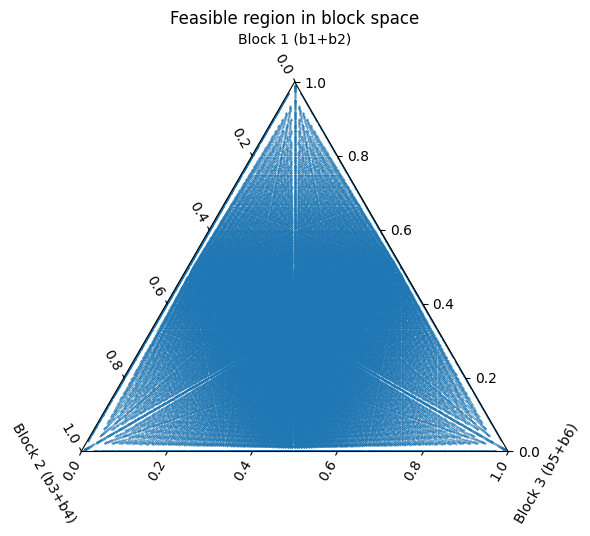

In [11]:
blocks2 = np.array(
    [
        bs[:, [0, 1]].sum(axis=1),
        bs[:, [2, 3]].sum(axis=1),
        bs[:, [4, 5]].sum(axis=1),
    ]
).T
# Plot probability simplex for blocks
import mpltern

ax = plt.subplot(111, projection="ternary")
ax.scatter(blocks2[:, 0], blocks2[:, 1], blocks2[:, 2],s=0.1, alpha=1)
ax.set_tlabel("Block 1 (b1+b2)")
ax.set_llabel("Block 2 (b3+b4)")
ax.set_rlabel("Block 3 (b5+b6)")
plt.title("Feasible region in block space")
plt.show()

In [12]:
import numpy as np


def b_from_x(x):
    x1, x2, x3 = x
    c = sum(x)
    b1 = x1/c * (x2 / (c - x1))
    b2 = x1/c * (x3 / (c - x1))
    b3 = x2/c * (x1 / (c - x2))
    b4 = x2/c * (x3 / (c - x2))
    b5 = x3/c * (x2 / (c - x3))
    b6 = x3/c * (x1 / (c - x3))
    # optional normalize numerical rounding: b_sum = sum([b1..b6])
    return np.array([b1, b2, b3, b4, b5, b6])


# sample x grid (log-grid via y to cover 0..1 well)
N = 120  # per axis; choose larger for higher resolution
x1s = np.linspace(1e-4, 2 - 1e-4, N)
x2s = np.linspace(1e-4, 2 - 1e-4, N)
x3s = np.linspace(1e-4, 2 - 1e-4, N)
bxs = []
for x1 in x1s:
    for x2 in x2s:
        for x3 in x3s:
            x = np.array([x1, x2, x3])
            b = b_from_x(x)
            bxs.append(b / b.sum())  # if you want to inspect normalized b
bxs = np.array(bxs)  # shape (N^3, 6)

In [13]:
grid_space = 500
grid = np.linspace(0.001, 1, grid_space)
X1, X2 = np.meshgrid(grid, grid)
X3 = 1 - X1 - X2
valid = X3 >= 0
X1, X2, X3 = X1[valid], X2[valid], X3[valid]
bs_grid = np.array([b_from_x([x1, x2, x3]) for x1, x2, x3 in zip(X1, X2, X3)])
blocks_grid = np.array(
    [
        bs_grid[:, [0, 1]].sum(axis=1),
        bs_grid[:, [2, 3]].sum(axis=1),
        bs_grid[:, [4, 5]].sum(axis=1),
    ]
).T

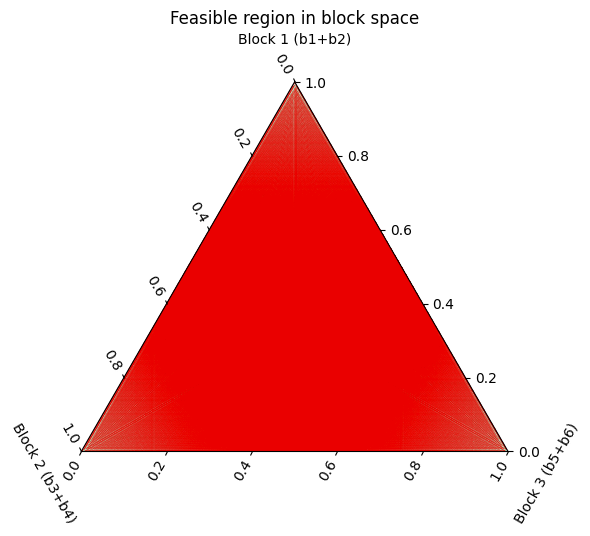

In [14]:
blocks2 = np.array(
    [
        bxs[:, [0, 1]].sum(axis=1),
        bxs[:, [2, 3]].sum(axis=1),
        bxs[:, [4, 5]].sum(axis=1),
    ]
).T
# Plot probability simplex for blocks
import mpltern

ax = plt.subplot(111, projection="ternary")
ax.scatter(blocks_grid[:, 0], blocks_grid[:, 1], blocks_grid[:, 2], s=0.001, alpha=1, color="green")
ax.scatter(blocks2[:, 0], blocks2[:, 1], blocks2[:, 2], s=0.001, alpha=1, color="red")
ax.set_tlabel("Block 1 (b1+b2)")
ax.set_llabel("Block 2 (b3+b4)")
ax.set_rlabel("Block 3 (b5+b6)")
plt.title("Feasible region in block space")
plt.show()

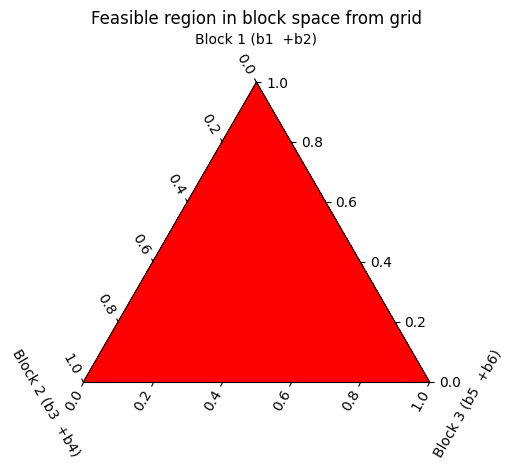

In [15]:

# Plot probability simplex for blocks
ax = plt.subplot(111, projection="ternary")
ax.scatter(blocks_grid[:, 0], blocks_grid[:, 1], blocks_grid[:, 2], s=.1, alpha=1, color='green')
ax.scatter(blocks2[:, 0], blocks2[:, 1], blocks2[:, 2], s=.1, alpha=1, color='red')

ax.set_tlabel('Block 1 (b1  +b2)')
ax.set_llabel('Block 2 (b3  +b4)')
ax.set_rlabel('Block 3 (b5  +b6)')
plt.title("Feasible region in block space from grid")
plt.tight_layout()
plt.savefig("feasible_region_blocks.png", dpi=300)
plt.show()

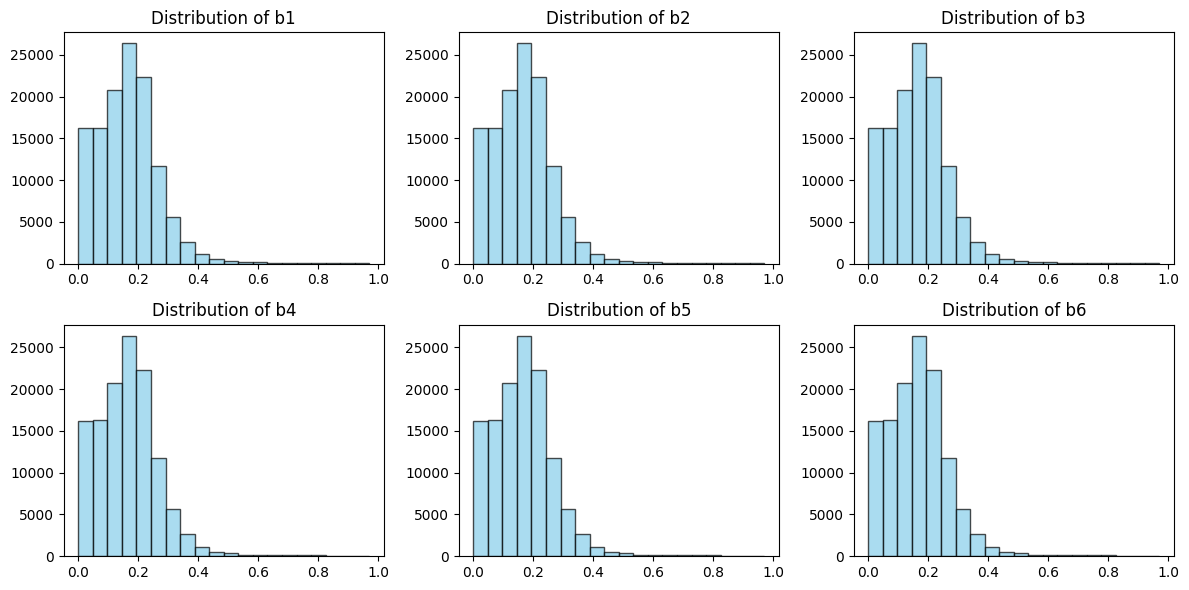

In [16]:
# Histograms for each b_i
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
for i in range(6):
    axes[i].hist(
        bs[:, i], bins=20, alpha=0.7, color="skyblue", edgecolor="black"
    )
    axes[i].set_title(f"Distribution of b{i+1}")
plt.tight_layout()
plt.show()

## Propotion of impossible distributions

In [17]:
for T in [10, 50, 100, 500, 1000, 10_000]:
    sampled_probs = np.random.dirichlet([T,T,T,T,T,T], size=100_000)
    mask = (abs(sampled_probs[:,[0,3,4]].prod(axis=1) - sampled_probs[:,[1,2,5]].prod(axis=1)) > 1e-6 )
    proportion_impossible = mask.mean()
    print(f"T={T}: Proportion of impossible distributions: {proportion_impossible:.4f}")

T=10: Proportion of impossible distributions: 0.9998
T=50: Proportion of impossible distributions: 0.9994
T=100: Proportion of impossible distributions: 0.9993
T=500: Proportion of impossible distributions: 0.9985
T=1000: Proportion of impossible distributions: 0.9981
T=10000: Proportion of impossible distributions: 0.9930



## Miscalibrated Plackettluce   

In [18]:
import itertools
import math

def calculate_pl_probs(weights):
    """Calculate Plackett-Luce probabilities for all rankings given weights.

    Args:
        weights (np.ndarray): Weights for each item, shape (n_items,).
    Returns:
        np.ndarray: Probabilities for each ranking, shape (n_rankings,).
    """
    result_dict = {}
    possible_rankings = itertools.permutations(range(1, len(weights) + 1))
    n_items = len(weights)
    n_rankings = math.factorial(n_items)
    ranking_probs = np.zeros(n_rankings)
    for i, ranking in enumerate(possible_rankings):
        prob = 1.0
        remaining_weights = weights.copy()
        for item in ranking:
            prob *= remaining_weights[item - 1] / remaining_weights.sum()
            remaining_weights[item - 1] = 0  # Remove item from consideration
        ranking_probs[i] = prob
        result_dict[tuple(ranking)] = prob
    return result_dict

def mallows_normalization_constant(n_items, dispersion):
    constant = 1.0
    for j in range(1, n_items + 1):
        constant *= 1 + sum([dispersion**k for k in range(1, j)])
    return 1 / constant


def calculate_mallows_probs(central_ranking, phi):
    """Calculate Mallows model probabilities for all rankings given central ranking and phi.

    Args:
        central_ranking (list): Central ranking as a list of item indices.
        phi (float): Dispersion parameter, 0 < phi <= 1.
    Returns:
        dict: Probabilities for each ranking.
    """
    result_dict = {}
    possible_rankings = itertools.permutations(range(1, len(central_ranking) + 1))
    n_items = len(central_ranking)
    n_rankings = math.factorial(n_items)
    ranking_probs = np.zeros(n_rankings)
    for i, ranking in enumerate(possible_rankings):
        # Calculate Kendall tau distance
        distance = sum(
            1
            for a, b in itertools.combinations(range(n_items), 2)
            if (ranking.index(central_ranking[a]) > ranking.index(central_ranking[b]))
        )
        prob = (phi ** distance) / mallows_normalization_constant(n_items, phi)
        ranking_probs[i] = prob
        result_dict[tuple(ranking)] = prob
    return result_dict
def get_pairwise_probs(probs_dict):
    """Calculate pairwise comparison probabilities from ranking probabilities.

    Args:
        probs_dict (dict): Dictionary with rankings as keys and their probabilities as values.
    Returns:
        dict: Pairwise comparison probabilities.
    """
    pairwise_probs = {}
    possible_rankings = list(probs_dict.keys())
    for i in range(1, len(possible_rankings[0]) + 1):
        for j in range(1, len(possible_rankings[0]) + 1):
            if i != j:
                pair = (i, j)
                pairwise_probs[pair] = sum(
                    prob
                    for ranking, prob in probs_dict.items()
                    if ranking.index(i) < ranking.index(j)
                )
    return pairwise_probs

pl_weights = np.array([0.5, 0.3, 0.2])
pl_weights_2 = np.array([0.5/2, 0.3/2, 0.2/2])
pl_probs = calculate_pl_probs(pl_weights)
pl_probs_2 = calculate_pl_probs(pl_weights_2)
pl_probs, pl_probs_2

({(1, 2, 3): np.float64(0.3),
  (1, 3, 2): np.float64(0.2),
  (2, 1, 3): np.float64(0.21428571428571427),
  (2, 3, 1): np.float64(0.08571428571428573),
  (3, 1, 2): np.float64(0.125),
  (3, 2, 1): np.float64(0.075)},
 {(1, 2, 3): np.float64(0.3),
  (1, 3, 2): np.float64(0.2),
  (2, 1, 3): np.float64(0.21428571428571427),
  (2, 3, 1): np.float64(0.08571428571428573),
  (3, 1, 2): np.float64(0.125),
  (3, 2, 1): np.float64(0.075)})

In [19]:
pl_probs_pairwise = get_pairwise_probs(pl_probs)
pl_probs_pairwise_2 = get_pairwise_probs(pl_probs_2)


pl_probs_pairwise, pl_probs_pairwise_2

({(1, 2): np.float64(0.625),
  (1, 3): np.float64(0.7142857142857143),
  (2, 1): np.float64(0.375),
  (2, 3): np.float64(0.6),
  (3, 1): np.float64(0.28571428571428575),
  (3, 2): np.float64(0.4)},
 {(1, 2): np.float64(0.625),
  (1, 3): np.float64(0.7142857142857143),
  (2, 1): np.float64(0.375),
  (2, 3): np.float64(0.6),
  (3, 1): np.float64(0.28571428571428575),
  (3, 2): np.float64(0.4)})

In [ ]:
def kl_divergence(p, q):
    """Calculate KL divergence D_KL(P || Q) for discrete distributions.

    Args:
        p (dict): First probability distribution.
        q (dict): Second probability distribution.
    Returns:
        float: KL divergence value.
    """
    kl_div = 0.0
    for key in p.keys():
        if p[key] > 0:
            kl_div += p[key] * np.log(p[key] / q.get(key, 1e-10))
    return kl_div

def best_model_for_mallows(mallos_probs):
    """Find the best fitting Plackett-Luce model for given Mallows probabilities.

    Args:
        mallos_probs (dict): Mallows model probabilities.
    Returns:
        dict: Best fitting Plackett-Luce model probabilities.
    """
    pl_probs = {}
    M_ranking = (3,2,1)
    c = np.sqrt([vals/mallows_probs[M_ranking] for key, vals in mallos_probs.items() if key != M_ranking]).sum()
    pl_probs[M_ranking] = (1 + np.sqrt(1 + 4*c) )/ 2
    for key, vals in mallos_probs.items():
        if key != M_ranking:
            pl_probs[key] = (np.sqrt(mallos_probs[M_ranking] / mallows_probs[key])) * 1/pl_probs[M_ranking]
    return pl_probs
    
    

pl_probs = calculate_pl_probs(np.array([50, 25, 1]))
pl_probs_uniform = calculate_pl_probs(np.array([1/3, 1/3, 1/3]))
mallows_probs = calculate_mallows_probs([1, 2, 3], phi=0.2)
kl_divergence(mallows_probs, pl_probs),
print("PL KL DIVERGENCE: ", kl_divergence(
    mallows_probs, pl_probs
))
print("PL BEST FIT KL DIVERGENCE: ", kl_divergence(
    mallows_probs, best_model_for_mallows(mallows_probs)
))

print("UNIFORM KL DIVERGENCE: ", kl_divergence(
    mallows_probs, pl_probs_uniform
))

PL KL DIVERGENCE:  2.240515747429425
25.652475842498525
PL BEST FIT KL DIVERGENCE:  7.896688081784643
UNIFORM KL DIVERGENCE:  3.4485985593891253


In [35]:
best_model_for_mallows(mallows_probs)

{(3, 2, 1): np.float64(5.589447498746649),
 (1, 2, 3): np.float64(0.016002068025515546),
 (1, 3, 2): np.float64(0.0357817118856286),
 (2, 1, 3): np.float64(0.0357817118856286),
 (2, 3, 1): np.float64(0.08001034012757771),
 (3, 1, 2): np.float64(0.08001034012757771)}

321.5243331583764 129.00668178441995
285.5145117561528 129.00668178441995
277.39125758952287 129.00668178441995
272.6645834600177 129.00668178441995
269.34333489137214 129.00668178441995
266.7950893361167 129.00668178441995
264.73694403660204 129.00668178441995
263.0176996766921 129.00668178441995
261.547015523035 129.00668178441995
260.26659152721857 129.00668178441995
259.13661363435926 129.00668178441995
258.1286854329736 129.00668178441995
257.2218451170894 129.00668178441995
256.40018082878294 129.00668178441995
255.6513316123706 129.00668178441995
254.96550648701862 129.00668178441995
254.33482059304907 129.00668178441995
253.7528328730609 129.00668178441995
253.2142160656064 129.00668178441995
252.7145160317698 129.00668178441995
252.24997288995755 129.00668178441995
251.81738584728458 129.00668178441995
251.41400952093073 129.00668178441995
251.0374733452877 129.00668178441995
250.6857181670535 129.00668178441995
250.35694581742413 129.00668178441995
250.04957860771827 129.0066

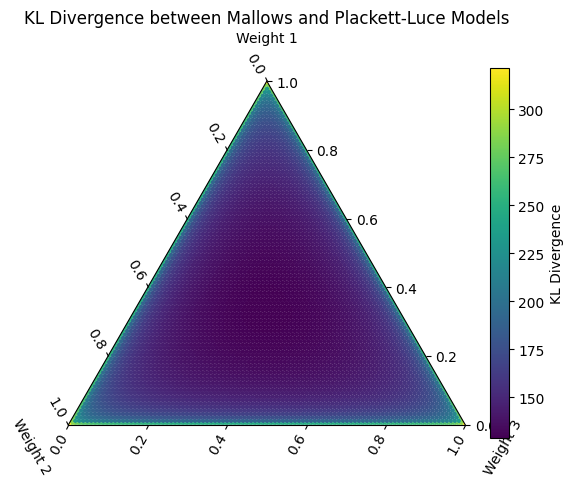

In [31]:
# Plot simplex for KL Divergence values
import mpltern
import matplotlib.pyplot as plt
import numpy as np

w1 = np.linspace(0.001, 0.998, 100)
w2 = np.linspace(0.001, 0.998, 100)
w1, w2 = np.meshgrid(w1, w2)
w3 = 1 - w1 - w2
valid = w3 >= 0
w1, w2, w3 = w1[valid], w2[valid], w3[valid]
kl_values = []
kl_smaller_uniform = []
for weight1, weight2, weight3 in zip(w1, w2, w3):
    pl_probs = calculate_pl_probs(np.array([weight1, weight2, weight3]))
    mallows_probs = calculate_mallows_probs([1, 2, 3], phi=1)
    kl = kl_divergence(mallows_probs, pl_probs)
    print(kl, kl_divergence(mallows_probs, pl_probs_uniform))
    kl_smaller_uniform.append(kl < kl_divergence(mallows_probs, pl_probs_uniform))
    kl_values.append(kl)
kl_values = np.array(kl_values)
ax = plt.subplot(111, projection="ternary")
sc = ax.scatter(w1, w2, w3, c=kl_values, cmap="viridis", s=5)
plt.colorbar(sc, label="KL Divergence")
ax.set_tlabel("Weight 1")
ax.set_llabel("Weight 2")
ax.set_rlabel("Weight 3")
plt.title("KL Divergence between Mallows and Plackett-Luce Models")
plt.show()

In [32]:
sum(kl_smaller_uniform) / len(kl_smaller_uniform)

np.float64(0.0)